<a href="https://colab.research.google.com/github/reddytian/dl-learning/blob/main/notebooks/day3_mnist_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3 — MLP on MNIST

Fully-connected network, 101,770 parameters, 5 epochs → ~97.5% test accuracy.

**Takeaway:** the ~1 point train/test gap is a fact about MNIST, not about the
modelling. Day 4 runs the identical loop on CIFAR-10 and gets a 21-point gap.

**What this covers**
- Loading image data with `DataLoader`
- A network with a non-linear activation (ReLU), and why that is the whole point
- The same five-step training loop as Day 2, now with 101,770 parameters instead of 2
- Evaluation: accuracy, confusion matrix, per-class metrics, overfitting check
- An experiment showing this architecture ignores spatial structure entirely —
  the gap Day 4's CNN closes

## 1. Load the data

No `Normalize` here, unlike Day 4. MNIST gets away with it: near-binary, mostly-black,
single channel, so raw `[0, 1]` is adequately scaled. CIFAR-10's three channels have
genuinely different means and spreads and do need standardizing.

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 452kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.20MB/s]


Train: 60000 images, Test: 10000 images
Batch shape: torch.Size([64, 1, 28, 28])


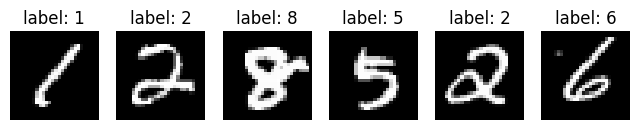

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)                      # reproducibility

transform = transforms.ToTensor()          # PIL uint8 [0,255] HWC -> float32 [0,1] CHW

train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=1000)

print(f'Train: {len(train_data)} images, Test: {len(test_data)} images')

images, labels = next(iter(train_loader))
print('Batch shape:', images.shape)        # [64, 1, 28, 28] -- channel dim is 1, not absent

plt.figure(figsize=(8, 2))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f'label: {labels[i].item()}')
    plt.axis('off')
plt.show()

## 2. Define the network

```
[64, 1, 28, 28]  →  Flatten  →  [64, 784]
                 →  Linear(784, 128) + ReLU  →  [64, 128]
                 →  Linear(128, 10)          →  [64, 10]
```

Parameter count: `784×128 + 128 = 100,480` plus `128×10 + 10 = 1,290` = **101,770**.

`nn.ReLU()` is the only non-linearity, and it is what makes this a neural network
rather than a logistic regression. Without it, two stacked `Linear` layers collapse
algebraically into one:

```
y = (x·W₁ + b₁)·W₂ + b₂ = x·(W₁W₂) + (b₁W₂ + b₂) = x·W' + b'
```

So a network without activations is a linear model however deep it is — exactly the
capacity ceiling that stalled the Day 2 parabola fit at loss 7.3. Removing `self.relu`
below drops accuracy to roughly 92%, because that is what the model becomes.

`Linear(128, 10)` outputs raw logits with no softmax: `nn.CrossEntropyLoss` applies
log-softmax internally, and adding another would double-apply it.

In [2]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()          # 28x28 image -> 784-length vector
        self.fc1 = nn.Linear(28 * 28, 128)   # hidden layer
        self.relu = nn.ReLU()                # the only non-linearity
        self.fc2 = nn.Linear(128, 10)        # one logit per digit

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Net().to(device)
print('Using device:', device)
print('parameters:', sum(p.numel() for p in model.parameters()))
print(model)

Using device: cpu
parameters: 101770
Net(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 3. Train

Compare this loop with Day 2's line-fitting exercise: identical five steps, 101,770
parameters instead of 2. The training machinery does not change with model complexity.

1. **forward** — predict
2. **loss** — measure how wrong
3. **zero_grad** — clear the previous step's gradients (they accumulate otherwise)
4. **backward** — autograd computes gradients
5. **step** — update the weights

Test accuracy is measured every epoch, not only at the end. Measuring once tells you
the final gap but not when it opened.

Epoch 1 | loss 0.3421 | train 0.9474 | test 0.9437 | gap +0.0037
Epoch 2 | loss 0.1531 | train 0.9673 | test 0.9639 | gap +0.0034
Epoch 3 | loss 0.1045 | train 0.9766 | test 0.9704 | gap +0.0062
Epoch 4 | loss 0.0789 | train 0.9821 | test 0.9736 | gap +0.0085
Epoch 5 | loss 0.0627 | train 0.9847 | test 0.9756 | gap +0.0091


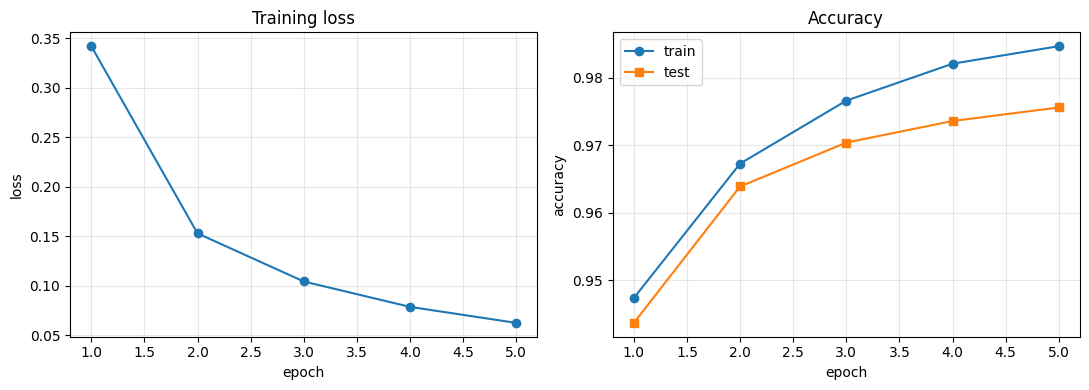

In [3]:
@torch.no_grad()
def accuracy(model, loader):
    model.eval(); correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        correct += (model(images).argmax(1) == labels).sum().item()
        total += labels.size(0)
    return correct / total

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

hist = {'loss': [], 'train_acc': [], 'test_acc': []}
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        y_pred = model(images)            # 1. forward
        loss = loss_fn(y_pred, labels)    # 2. loss
        optimizer.zero_grad()             # 3. zero gradients
        loss.backward()                   # 4. backward
        optimizer.step()                  # 5. update

        running_loss += loss.item() * labels.size(0)

    avg_loss = running_loss / len(train_data)
    tr, te = accuracy(model, train_loader), accuracy(model, test_loader)
    hist['loss'].append(avg_loss); hist['train_acc'].append(tr); hist['test_acc'].append(te)
    print(f'Epoch {epoch + 1} | loss {avg_loss:.4f} | train {tr:.4f} | '
          f'test {te:.4f} | gap {tr - te:+.4f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(range(1, 6), hist['loss'], 'o-')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss'); ax[0].grid(alpha=.3)
ax[0].set_title('Training loss')
ax[1].plot(range(1, 6), hist['train_acc'], 'o-', label='train')
ax[1].plot(range(1, 6), hist['test_acc'],  's-', label='test')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('accuracy'); ax[1].legend(); ax[1].grid(alpha=.3)
ax[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

## 4. Evaluate

Nothing here is specific to deep learning — `accuracy_score`, `confusion_matrix` and
`classification_report` are the same scikit-learn tools used for any classifier. The
model changed; the evaluation methodology did not.

`torch.no_grad()` disables graph construction: faster, less memory, and a structural
guarantee that evaluation cannot influence the weights. `model.eval()` switches dropout
and BatchNorm to inference mode — this network has neither, so it is currently a no-op,
but Day 5's pretrained ResNet is full of BatchNorm and omitting it there silently
corrupts the numbers.

Test accuracy: 97.56% +/- 0.15 (1 SE, n=10000)



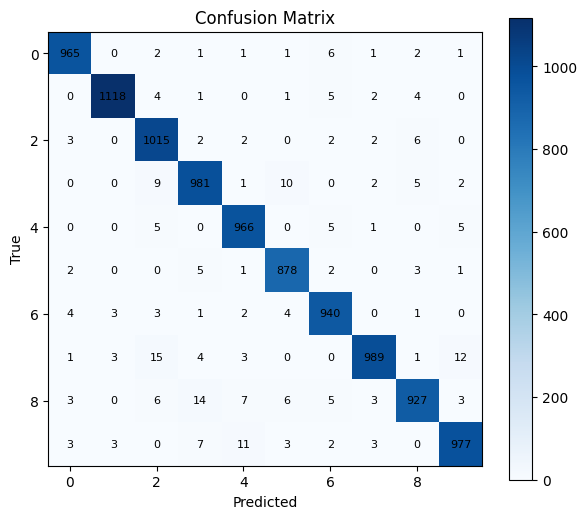

              precision    recall  f1-score   support

           0      0.984     0.985     0.984       980
           1      0.992     0.985     0.989      1135
           2      0.958     0.984     0.971      1032
           3      0.966     0.971     0.968      1010
           4      0.972     0.984     0.978       982
           5      0.972     0.984     0.978       892
           6      0.972     0.981     0.977       958
           7      0.986     0.962     0.974      1028
           8      0.977     0.952     0.964       974
           9      0.976     0.968     0.972      1009

    accuracy                          0.976     10000
   macro avg      0.975     0.976     0.975     10000
weighted avg      0.976     0.976     0.976     10000



In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
se = np.sqrt(acc * (1 - acc) / len(all_labels))
print(f'Test accuracy: {acc*100:.2f}% +/- {se*100:.2f} (1 SE, n={len(all_labels)})\n')

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar(); plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)
plt.show()

print(classification_report(all_labels, all_preds, digits=3))

## 5. Overfitting check

| situation | train acc | test acc | meaning |
|---|---|---|---|
| healthy | high | high | generalizes |
| overfitting | very high | lower | memorized the training data |
| underfitting | low | low | too simple, or undertrained |

In [5]:
tr = accuracy(model, train_loader)
te = accuracy(model, test_loader)
print(f'Train accuracy: {tr*100:.2f}%')
print(f'Test  accuracy: {te*100:.2f}%')
print(f'Gap (train - test): {(tr - te)*100:+.2f} pt')

Train accuracy: 98.47%
Test  accuracy: 97.56%
Gap (train - test): +0.91 pt


**A ~1 point gap here is close to unavoidable, and says little about the modelling.**
MNIST has 60,000 near-noise-free examples, black backgrounds, centred strokes, and
almost no intra-class variation — one "7" looks much like another.

Do not carry the intuition forward. Day 4 runs this same loop, optimizer and loss on
CIFAR-10 and gets a **+21 point** gap. The difference is entirely the data.

## 6. Experiment — this network ignores spatial structure

`nn.Flatten()` discards the 2-D geometry. After flattening, pixels (3,4) and (3,5) —
neighbours in the image — become positions 88 and 89 in a vector, no more related than
positions 88 and 512. The network has to rediscover locality from scratch, separately
for all 784 positions.

To test that claim: apply **one fixed random permutation to all images**, identically
for every one, and retrain. The images become unreadable to a human. If the network
were using spatial arrangement, accuracy would collapse.

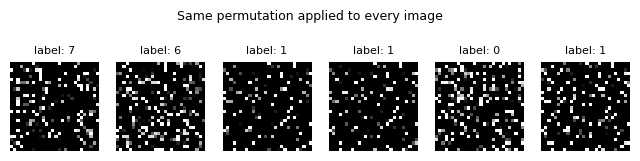

Epoch 1 | test 0.9453
Epoch 2 | test 0.9646
Epoch 3 | test 0.9670
Epoch 4 | test 0.9729
Epoch 5 | test 0.9765

original  test accuracy: 0.9756
permuted  test accuracy: 0.9765


In [6]:
torch.manual_seed(0)
perm = torch.randperm(28 * 28)

class NetPermuted(Net):
    def forward(self, x):
        x = self.flatten(x)
        x = x[:, perm]                    # same fixed shuffle for every image
        x = self.relu(self.fc1(x))
        return self.fc2(x)

# What the permuted digits look like
plt.figure(figsize=(8, 2))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images[i].flatten()[perm].reshape(28, 28), cmap='gray')
    plt.title(f'label: {labels[i].item()}', fontsize=8)
    plt.axis('off')
plt.suptitle('Same permutation applied to every image', fontsize=9)
plt.show()

torch.manual_seed(42)
model_p = NetPermuted().to(device)
opt_p = torch.optim.Adam(model_p.parameters(), lr=0.001)

for epoch in range(5):
    model_p.train()
    for imgs, labs in train_loader:
        imgs, labs = imgs.to(device), labs.to(device)
        loss = loss_fn(model_p(imgs), labs)
        opt_p.zero_grad(); loss.backward(); opt_p.step()
    print(f'Epoch {epoch+1} | test {accuracy(model_p, test_loader):.4f}')

print(f'\noriginal  test accuracy: {te:.4f}')
print(f'permuted  test accuracy: {accuracy(model_p, test_loader):.4f}')

**Accuracy is essentially unchanged.** The fully-connected network never used the
spatial arrangement, so destroying it costs nothing.

Run the same test on Day 4's CNN and accuracy collapses — because convolution's entire
premise is that nearby pixels belong together, the same assumption behind every 3×3
kernel in classical image processing.

That contrast is the argument for CNNs on images: not that they are more complex, but
that they **encode a correct prior that a fully-connected network lacks**.

## Summary

- A 101,770-parameter fully-connected network reaches ~97.5% test accuracy on MNIST in
  5 epochs.
- The training loop is unchanged from Day 2 — only the model grew.
- ReLU is what lifts this above a linear model (~92%); without it the two `Linear`
  layers collapse into one.
- Evaluation is ordinary scikit-learn practice. The model being a neural network
  changes nothing about how it is assessed.
- The ~1 point gap reflects how easy MNIST is, not how well the model generalizes.
- The permutation experiment shows this architecture uses no spatial structure at all.

### Known limitations

- **No validation split.** The test set is used directly. Acceptable with zero tuning,
  but choosing hidden size or epoch count by test accuracy would make the number
  optimistic. Day 6 introduces a proper three-way split.
- **Single run.** No seed sweep, so the reported accuracy carries unquantified
  run-to-run variance. Day 6 measures that variance directly and finds it larger than
  expected.
- **5 epochs chosen by convention**, not by any convergence criterion.

**Next:** convolutional networks, which exploit the 2-D structure this notebook just
demonstrated is being thrown away.